In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Japan Segmentation, Morphological Operations, Object Properties in Images
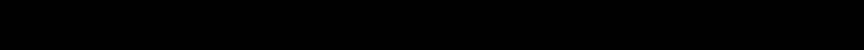
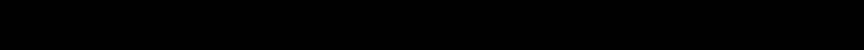
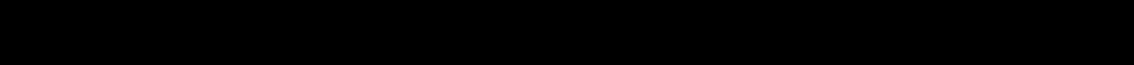

## Images Used
   - Shogi Board https://www.fun-japan.jp/my/articles/9564

In [2]:
def show_pair(a, b, titles=("Original", "Processed"), figsize=(10, 5), cmap='gray'):
    plt.figure(figsize=figsize)

    # left
    plt.subplot(1, 2, 1)
    if a.ndim == 2:
        plt.imshow(a, cmap=cmap)
    else:
        plt.imshow(a)
    plt.title(titles[0])
    plt.axis('off')

    # right
    plt.subplot(1, 2, 2)
    if b.ndim == 2:
        plt.imshow(b, cmap=cmap)
    else:
        plt.imshow(b)
    plt.title(titles[1])
    plt.axis('off')

    plt.show()

In [3]:
def load_rgb(path: str, dummy: bool = False, size: tuple[int, int] = (720, 1080)) -> np.ndarray:
    if os.path.exists(path) and not dummy:
        img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            dummy = True
        else:
            return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # dummy: colorful gradient + noise
    h, w = size
    y = np.linspace(0, 1, h)[:, None]
    x = np.linspace(0, 1, w)[None, :]
    r = x
    g = y
    b = 1 - 0.5 * (x + y)
    img = np.stack([r, g, b], axis=2)
    img += 0.05 * np.random.RandomState(42).randn(h, w, 3)
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)


In [4]:
def save_rgb(path: str, img_rgb: np.ndarray):
    bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(path, bgr)

## Day 9

### Use Case (Japan) – Go Board Segmentation

Automatically **segment and count Go stones** from overhead board photos to reconstruct the game state (stone counts and positions).

#### Problem
Go boards (19×19 grid) can be densely packed with black/white stones that:
- Touch or nearly touch each other
- Show reflections and lighting variation

We need to **detect each stone and its exact grid intersection** from a single image.

#### Why
- Go is a major traditional game and a clean benchmark for grid-based vision tasks.
- Automatic board recognition enables:
  - Digital game recording from real boards
  - Training data for Go AI from amateur/pro play
  - A controlled proxy task for methods later applied to complex scenes (e.g., shelves, vending machines).

#### Target Outputs per Image
- **Total stones** on the board
- **Black vs. white stone counts**
- **Coordinates of each stone** (board intersections)
- Optional:
  - Approximate **territory regions**
  - List of **empty intersections**
  - Basic group/shape features (large groups, eyes)

#### Selected Image
- Overhead view of a **single Go board** on a table
- Standard grid with many intersections
- Numerous **black and white stones** placed on the board, often touching, ideal for segmentation and counting.


In [5]:
GO_PATH = "Data/Go.png"
img_go = load_rgb(GO_PATH)

save_rgb('images/jo.jpg', img_go)

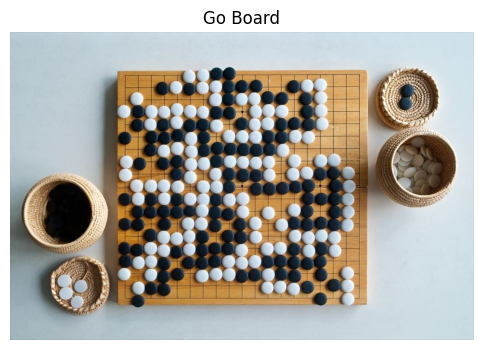

In [6]:
plt.figure(figsize=(6,4)); plt.imshow(img_go); plt.title("Go Board"); plt.axis("off"); plt.show()

## Day 10

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
from skimage.morphology import closing, opening, disk, remove_small_objects
from skimage.measure import label, regionprops

In [8]:
def crop_board_custom(
    img: np.ndarray,
    top_ratio: float = 0.1,
    bottom_ratio: float = 0.1,
    left_ratio: float = 0.1,
    right_ratio: float = 0.1,
) -> np.ndarray:

    h, w = img.shape[:2]

    # convert ratios to pixel offsets
    top    = int(h * top_ratio)
    bottom = int(h * bottom_ratio)
    left   = int(w * left_ratio)
    right  = int(w * right_ratio)

    y0 = top
    y1 = h - bottom
    x0 = left
    x1 = w - right

    # safety clamp
    y0 = max(0, min(y0, h-1))
    y1 = max(y0+1, min(y1, h))
    x0 = max(0, min(x0, w-1))
    x1 = max(x0+1, min(x1, w))

    return img[y0:y1, x0:x1]

In [9]:
img_board = crop_board_custom(
    img_go,
    top_ratio=0.1,
    bottom_ratio=0.1,
    left_ratio=0.225,
    right_ratio=0.225,
)

### Crop to Board

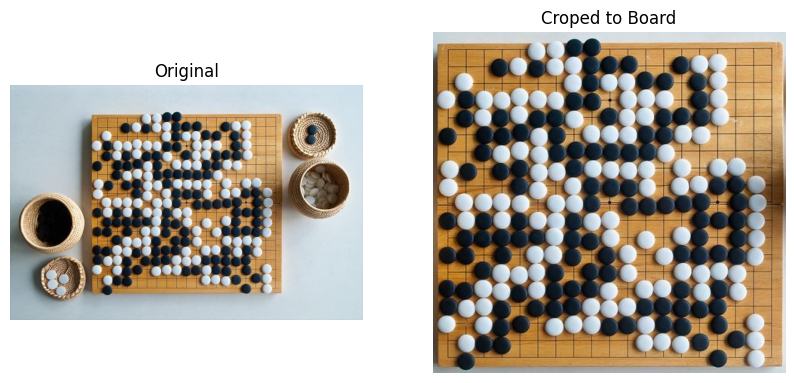

In [10]:
show_pair(img_go, img_board, titles=("Original", "Croped to Board"))

In [43]:
def kmeans_segment_board(
    img_board: np.ndarray,
    K: int = 3,
    use_lab_weighted: bool = True,
    blur_ksize: int = 0,
    max_iter: int = 20,
    attempts: int = 5,
) -> tuple[np.ndarray, np.ndarray]:

    img = img_board.copy()

    if blur_ksize and blur_ksize > 1:
        if blur_ksize % 2 == 0:
            blur_ksize += 1
        img = cv2.GaussianBlur(img, (blur_ksize, blur_ksize), 0)

    if use_lab_weighted:
        img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)
        L, a, b = cv2.split(img_lab)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        L = clahe.apply(L.astype(np.uint8)).astype(np.float32)

        L_w = L * 0.4       # brightness: low weight
        a_w = a * 1.2       # chroma: higher weight
        b_w = b * 1.2

        feat = np.stack([L_w, a_w, b_w], axis=-1)   # (H, W, 3)
        Z = feat.reshape((-1, 3)).astype(np.float32)

    else:
        Z = img.reshape((-1, 3)).astype(np.float32)

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        max_iter,
        1.0
    )

    # noinspection PyTypeChecker
    _, labels_flat, _ = cv2.kmeans(
        Z, K, None, criteria, attempts, cv2.KMEANS_RANDOM_CENTERS
    )

    labels_km = labels_flat.reshape(img_board.shape[:2])

    h, w = img_board.shape[:2]
    centers_rgb = np.zeros((K, 3), dtype=np.float32)
    for k in range(K):
        mask = (labels_km == k)
        if np.any(mask):
            centers_rgb[k] = img_board[mask].mean(axis=0)
    centers_rgb = centers_rgb.astype(np.uint8)

    return labels_km, centers_rgb

### K-Means Segmentation

In [44]:
labels_km, centers_rgb = kmeans_segment_board(
    img_board,
    K=3,
    use_lab_weighted=True,  # <- now using Lab with reduced L influence
    blur_ksize=1,
    max_iter=20,
    attempts=5,
)

print("[K-means] Cluster centers (RGB):\n", centers_rgb)

[K-means] Cluster centers (RGB):
 [[ 39  40  42]
 [175 130  76]
 [198 206 210]]


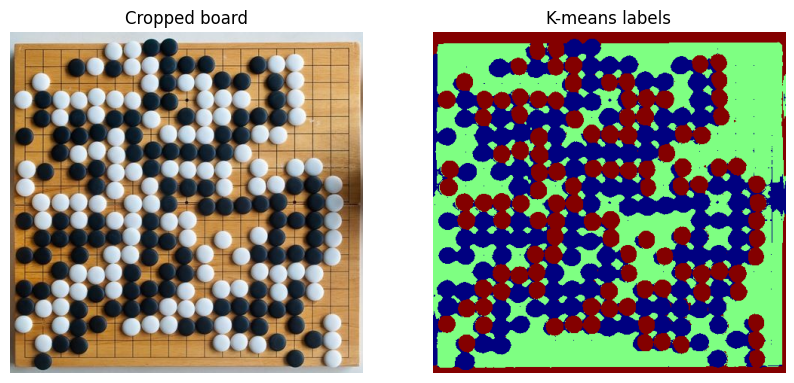

In [45]:
labels_norm = (255 * labels_km / (3 - 1 + 1e-6)).astype(np.uint8)
labels_color = cv2.applyColorMap(labels_norm, cv2.COLORMAP_JET)
labels_color_rgb = cv2.cvtColor(labels_color, cv2.COLOR_BGR2RGB)

show_pair(img_board, labels_color_rgb,
          titles=("Cropped board", "K-means labels"))